In [1]:
# %% [markdown]
# ## Cell 01 — Configuration
#
# Central configuration block. Modify these flags to control notebook behaviour.

# %%
# ── LLM mode ─────────────────────────────────────────────────────────────────
USE_REAL_LLM         = False   # True  → call Anthropic API
                               # False → use offline deterministic fallback

# ── Caching ───────────────────────────────────────────────────────────────────
LOAD_CACHED_OUTPUTS  = True    # True  → load from cache if available
                               # False → always regenerate (API or fallback)

# ── Output control ────────────────────────────────────────────────────────────
ENABLE_VERBOSE_LOGGING = False  # True → print per-clause detail during pipeline
EXPORT_OUTPUTS         = True   # True → save JSON, CSV, txt to OUTPUT_DIR

# ── Paths ─────────────────────────────────────────────────────────────────────
NB01_DIR   = "legal_bert_classifier"
NB02_DIR   = "ontology_artifacts"
CACHE_DIR  = "nb03_cache"
OUTPUT_DIR = "nb03_outputs"

# ── Segmentation ──────────────────────────────────────────────────────────────
MIN_CLAUSE_LENGTH = 40    # characters — shorter segments are discarded
MAX_CLAUSE_LENGTH = 1500  # characters — longer segments are truncated

# ── Inference ─────────────────────────────────────────────────────────────────
MAX_LENGTH     = 256
LLM_MODEL      = "claude-sonnet-4-20250514"
LLM_MAX_TOKENS = 1024

print("Configuration loaded.")
print(f"  USE_REAL_LLM:        {USE_REAL_LLM}")
print(f"  LOAD_CACHED_OUTPUTS: {LOAD_CACHED_OUTPUTS}")
print(f"  EXPORT_OUTPUTS:      {EXPORT_OUTPUTS}")

Configuration loaded.
  USE_REAL_LLM:        False
  LOAD_CACHED_OUTPUTS: True
  EXPORT_OUTPUTS:      True


In [2]:
# %% [markdown]
# ## Cell 02 — Imports

# %%
import os
import re
import json
import hashlib
import textwrap
import warnings
import numpy as np
import pandas as pd
import networkx as nx
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime
from transformers import AutoTokenizer, AutoModelForSequenceClassification

if USE_REAL_LLM:
    import anthropic

warnings.filterwarnings("ignore")

# Create required directories
for _dir in [CACHE_DIR, OUTPUT_DIR]:
    os.makedirs(_dir, exist_ok=True)

print("Imports complete.")
print(f"PyTorch: {torch.__version__}")

Imports complete.
PyTorch: 2.11.0


In [3]:
# %% [markdown]
# ## Cell 03 — Load Notebook 01 Artifacts (Legal-BERT)
#
# Inference-only. No retraining. No preprocessing pipeline reconstruction.

# %%
DEVICE = torch.device("cpu")

try:
    tokenizer     = AutoTokenizer.from_pretrained(NB01_DIR)
    model         = AutoModelForSequenceClassification.from_pretrained(NB01_DIR)
    label_classes = np.load(os.path.join(NB01_DIR, "label_classes.npy"), allow_pickle=True)
    model         = model.to(DEVICE)
    model.eval()
    NUM_CLASSES   = len(label_classes)
    print(f"Legal-BERT loaded from: {NB01_DIR}")
    print(f"Clause types: {NUM_CLASSES}  |  Labels: {list(label_classes)}")
except Exception as e:
    raise RuntimeError(
        f"Failed to load Notebook 01 artifacts from '{NB01_DIR}'.\n"
        f"Ensure Notebook 01 has been run and artifacts are present.\n"
        f"Original error: {e}"
    )

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Legal-BERT loaded from: legal_bert_classifier
Clause types: 8  |  Labels: ['change_of_control', 'confidentiality_non_compete', 'governing_law', 'intellectual_property', 'limitation_of_liability', 'payment', 'termination', 'warranties']


In [4]:
# %% [markdown]
# ## Cell 04 — Load Notebook 02 Artifacts (Ontology)
#
# Loads the ontology graph and enriched dataset. No graph reconstruction.

# %%
try:
    G           = nx.read_graphml(os.path.join(NB02_DIR, "ontology_graph.graphml"))
    df_enriched = pd.read_csv(os.path.join(NB02_DIR, "cuad_enriched_dataset.csv"))
    edges_df    = pd.read_csv(os.path.join(NB02_DIR, "ontology_edges.csv"))
    print(f"Ontology graph:   {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    print(f"Enriched dataset: {df_enriched.shape[0]} rows")
except Exception as e:
    raise RuntimeError(
        f"Failed to load Notebook 02 artifacts from '{NB02_DIR}'.\n"
        f"Ensure Notebook 02 has been run and artifacts are present.\n"
        f"Original error: {e}"
    )

Ontology graph:   40 nodes, 75 edges
Enriched dataset: 6226 rows


In [5]:
# %% [markdown]
# ## Cell 05 — Lightweight Symbolic Query Helpers
#
# Minimal re-exposure of NB02 symbolic reasoning — query-only, no graph rebuild.
#
# Note: These functions implement heuristic symbolic reasoning derived from
# the manually constructed ontology schema in Notebook 02. Results reflect
# the ontology's rule-based mappings, not probabilistic inference.

# %%
_ALL_RISK_DOMAINS = 6  # Fixed count from NB02 ontology schema


def ontology_get(relation: str, source: str) -> list[str]:
    """Return all targets from ontology edges matching (source, relation)."""
    try:
        return edges_df.loc[
            (edges_df["source"] == source) & (edges_df["relation"] == relation),
            "target"
        ].tolist()
    except Exception:
        return []


def get_risk_domains(clause_type: str)       -> list[str]: return ontology_get("increases_risk", clause_type)
def get_legal_concepts(clause_type: str)     -> list[str]: return ontology_get("relates_to",     clause_type)
def get_contract_elements(clause_type: str)  -> list[str]: return ontology_get("governs",        clause_type)
def get_dependencies(clause_type: str)       -> list[str]: return ontology_get("depends_on",     clause_type)


def get_dependents(clause_type: str) -> list[str]:
    try:
        return edges_df.loc[
            (edges_df["target"] == clause_type) & (edges_df["relation"] == "depends_on"),
            "source"
        ].tolist()
    except Exception:
        return []


def compute_risk_score(clause_type: str) -> float:
    """
    Heuristic symbolic risk score: fraction of total risk domains activated.
    Normalised to [0, 1]. Higher scores indicate broader risk exposure
    as defined by the ontology schema — not a legal risk assessment.
    """
    return round(len(get_risk_domains(clause_type)) / _ALL_RISK_DOMAINS, 4)


print("Symbolic query helpers ready.")

Symbolic query helpers ready.


In [6]:
# %% [markdown]
# ## Cell 06 — Legal-BERT Inference Function

# %%
def classify_clause(text: str) -> dict:
    """
    Classify a clause text using the fine-tuned Legal-BERT model.
    Returns clause_type, confidence, and all class probabilities.
    Returns a safe fallback dict on inference failure.
    """
    try:
        encoding = tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )
        input_ids      = encoding["input_ids"].to(DEVICE)
        attention_mask = encoding["attention_mask"].to(DEVICE)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs   = torch.softmax(outputs.logits, dim=1).squeeze().cpu().numpy()

        predicted_idx   = int(np.argmax(probs))
        predicted_label = label_classes[predicted_idx]
        confidence      = float(probs[predicted_idx])

        return {
            "clause_type": predicted_label,
            "confidence":  round(confidence, 4),
            "all_scores":  {label_classes[i]: round(float(p), 4) for i, p in enumerate(probs)},
        }

    except Exception as e:
        if ENABLE_VERBOSE_LOGGING:
            print(f"  [WARN] classify_clause failed: {e}")
        return {
            "clause_type": label_classes[0] if len(label_classes) > 0 else "unknown",
            "confidence":  0.0,
            "all_scores":  {},
            "error":       str(e),
        }


print("Legal-BERT inference function ready.")

Legal-BERT inference function ready.


In [7]:
# %% [markdown]
# ## Cell 07 — Clause Segmentation
#
# Lightweight rule-based segmentation. Splits raw contract text into
# individual clause candidates using numbered section headers, ALL CAPS
# headings, and paragraph-boundary fallback.
#
# Note: This is a heuristic approach. Complex nested clause structures,
# schedules, and annexures may not be segmented perfectly. Results should
# be treated as best-effort extraction, not guaranteed complete parsing.

# %%
_SECTION_PATTERN = re.compile(
    r"""
    (?:^|\n)
    (?:
        \d+\.\d*\s+[A-Z]           |   # 1.1 Heading
        \d+\s+[A-Z]                |   # 1 Heading
        [A-Z][A-Z\s]{4,}[.:]       |   # ALL CAPS HEADING. or :
        (?:Section|Article|Clause)\s+\d+   # Section/Article/Clause N
    )
    """,
    re.VERBOSE | re.MULTILINE,
)


def segment_clauses(text: str) -> list[str]:
    """
    Split raw contract text into individual clause candidates.

    Strategy (in order):
      1. Normalise whitespace and line endings.
      2. Attempt section-header splitting.
      3. Fall back to paragraph splitting if < 2 sections found.
      4. Filter short/empty segments.
      5. Truncate overly long segments.
      6. Deduplicate identical segments.

    Heuristic approach — not guaranteed to handle all contract structures.
    """
    if not text or not text.strip():
        return []

    # Normalise line endings and collapse excess blank lines
    text = re.sub(r"\r\n|\r", "\n", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = re.sub(r"[ \t]+", " ", text)  # collapse inline whitespace

    # Attempt header-based split
    segments = [s.strip() for s in _SECTION_PATTERN.split(text) if s and s.strip()]

    # Fall back to paragraph split
    if len(segments) < 2:
        segments = [s.strip() for s in text.split("\n\n") if s.strip()]

    # Further split any remaining very long segments on double-newline
    expanded = []
    for seg in segments:
        if len(seg) > MAX_CLAUSE_LENGTH * 1.5:
            sub = [s.strip() for s in seg.split("\n\n") if s.strip()]
            expanded.extend(sub if sub else [seg])
        else:
            expanded.append(seg)
    segments = expanded

    # Filter, truncate, deduplicate
    seen    = set()
    clauses = []
    for seg in segments:
        seg = seg.strip()
        if len(seg) < MIN_CLAUSE_LENGTH:
            continue
        if len(seg) > MAX_CLAUSE_LENGTH:
            seg = seg[:MAX_CLAUSE_LENGTH] + "..."
        # Simple dedup on first 120 chars (avoids repeated boilerplate)
        key = seg[:120].lower()
        if key in seen:
            continue
        seen.add(key)
        clauses.append(seg)

    return clauses


# Smoke test
_test = """
1. TERMINATION
Either party may terminate this agreement upon 30 days written notice.

2. GOVERNING LAW
This Agreement shall be governed by the laws of the State of New York.
"""
_segs = segment_clauses(_test)
print(f"Segmentation test: {len(_segs)} clauses extracted")
for i, s in enumerate(_segs, 1):
    print(f"  [{i}] {s[:80]}")

Segmentation test: 2 clauses extracted
  [1] ERMINATION
Either party may terminate this agreement upon 30 days written notice
  [2] OVERNING LAW
This Agreement shall be governed by the laws of the State of New Yo


In [8]:
# %% [markdown]
# ## Cell 08 — Prompt Engineering Templates

# %%
SYSTEM_PROMPT = """You are a senior legal analyst specialising in commercial contract review.
You receive structured legal intelligence about a contract clause and produce clear, accurate explanations.

Your outputs must be:
- Precise but accessible to non-lawyers
- Grounded only in the provided clause and context
- Structured exactly as requested, using the exact section headers provided
- Free of speculation beyond the clause text"""


def build_clause_explanation_prompt(
    clause_text: str,
    clause_type: str,
    confidence: float,
    legal_concepts: list[str],
    risk_domains: list[str],
    contract_elements: list[str],
    dependencies: list[str],
    risk_score: float,
) -> str:
    return f"""You have been given a legal clause with the following structured analysis:

CLAUSE TEXT:
\"\"\"{clause_text}\"\"\"

CLASSIFIER OUTPUT:
- Predicted clause type: {clause_type}
- Classifier confidence: {confidence:.0%}

ONTOLOGY CONTEXT (heuristic symbolic reasoning):
- Legal concepts instantiated: {", ".join(legal_concepts) if legal_concepts else "none identified"}
- Risk domains activated: {", ".join(risk_domains) if risk_domains else "none identified"}
- Contract elements governed: {", ".join(contract_elements) if contract_elements else "none identified"}
- Depends on clause types: {", ".join(dependencies) if dependencies else "none identified"}
- Symbolic risk score: {risk_score:.0%} (heuristic — not a legal risk assessment)

Produce a structured explanation with EXACTLY these four section headers on their own lines:

PLAIN ENGLISH SUMMARY:
(2-3 sentences. What does this clause say in plain language?)

LEGAL IMPLICATIONS:
(2-3 sentences. What legal obligations, rights, or consequences does this clause create?)

BUSINESS IMPLICATIONS:
(2-3 sentences. What does this mean practically for the parties involved?)

RISK INTERPRETATION:
(2-3 sentences. What risks does this clause create, limit, or transfer? Reference the risk domains above.)"""


def build_contract_risk_summary_prompt(
    clause_summaries: list[dict],
    contract_title: str = "Contract",
) -> str:
    clause_lines = "\n".join([
        f"- [{c['clause_type'].upper()}] (risk score: {c['risk_score']:.0%}): {c['plain_summary'][:120]}"
        for c in clause_summaries
        if c.get("plain_summary")
    ])
    high_risk = [c for c in clause_summaries if c.get("risk_score", 0) >= 0.4]

    return f"""You are reviewing a legal contract titled: "{contract_title}".

The following clauses have been identified, classified, and risk-scored using a hybrid AI pipeline
(transformer classification + symbolic ontology reasoning):

{clause_lines}

HIGH RISK CLAUSES FLAGGED: {len(high_risk)} of {len(clause_summaries)}

Note: Risk scores are heuristic symbolic approximations, not formal legal assessments.

Produce a structured contract-level intelligence report with EXACTLY these section headers on their own lines:

EXECUTIVE SUMMARY:
(3-4 sentences. Overall assessment of the contract's legal posture.)

KEY RISK AREAS:
(Bullet list. Identify the top 3 risk areas and which clauses drive them.)

CRITICAL DEPENDENCIES:
(2-3 sentences. Which clause types interact or depend on each other in ways that matter?)

BUSINESS RECOMMENDATIONS:
(Bullet list. 3-4 actionable recommendations for a business stakeholder reviewing this contract.)

OVERALL RISK RATING: [LOW / MEDIUM / HIGH / CRITICAL]
(One sentence justification.)"""


print("Prompt templates defined.")

Prompt templates defined.


In [9]:
# %% [markdown]
# ## Cell 09 — LLM Response Parsing
#
# Robust section parser — tolerates missing sections, formatting deviations,
# and malformed responses without crashing the pipeline.

# %%
_CLAUSE_SECTIONS   = ["PLAIN ENGLISH SUMMARY", "LEGAL IMPLICATIONS",
                       "BUSINESS IMPLICATIONS",  "RISK INTERPRETATION"]

_CONTRACT_SECTIONS = ["EXECUTIVE SUMMARY",      "KEY RISK AREAS",
                       "CRITICAL DEPENDENCIES",  "BUSINESS RECOMMENDATIONS",
                       "OVERALL RISK RATING"]


def _parse_llm_sections(text: str, section_names: list[str]) -> dict[str, str]:
    """
    Extract named sections from a structured LLM response.

    Tolerates:
    - Missing sections (filled with empty string)
    - Extra whitespace around headers
    - Colons present or absent after headers
    - Mixed capitalisation
    - Sections appearing in any order

    Never raises — always returns a complete dict with all expected keys.
    """
    if not text:
        return {s: "" for s in section_names}

    sections = {s: "" for s in section_names}

    # Build pattern that matches any section header (case-insensitive, optional colon)
    escaped  = [re.escape(s) for s in section_names]
    combined = "|".join(escaped)
    pattern  = re.compile(
        rf"^\s*({combined})\s*:?\s*$",
        re.IGNORECASE | re.MULTILINE,
    )

    parts = pattern.split(text)
    # parts alternates: [preamble, header, content, header, content, ...]
    i = 1
    while i < len(parts) - 1:
        raw_header = parts[i].strip().upper()
        content    = parts[i + 1].strip() if i + 1 < len(parts) else ""

        # Match raw_header to canonical section name
        for name in section_names:
            if name.upper() == raw_header:
                sections[name] = content
                break

        i += 2

    return sections


def _safe_str(val) -> str:
    """Coerce any value to a non-None string safely."""
    if val is None:
        return ""
    return str(val).strip()


print("LLM section parser ready.")

LLM section parser ready.


In [10]:
# %% [markdown]
# ## Cell 10 — Caching Layer

# %%
def _cache_key(text: str) -> str:
    """Generate a short deterministic cache key from input text."""
    return hashlib.md5(text.encode("utf-8")).hexdigest()[:16]


def _cache_path(key: str, prefix: str = "clause") -> str:
    return os.path.join(CACHE_DIR, f"{prefix}_{key}.json")


def _load_cache(key: str, prefix: str = "clause") -> dict | None:
    path = _cache_path(key, prefix)
    if os.path.exists(path):
        try:
            with open(path, "r", encoding="utf-8") as f:
                return json.load(f)
        except Exception:
            return None
    return None


def _save_cache(key: str, data: dict, prefix: str = "clause") -> None:
    path = _cache_path(key, prefix)
    try:
        # Sanitise for JSON serialisability
        clean = _make_json_safe(data)
        with open(path, "w", encoding="utf-8") as f:
            json.dump(clean, f, indent=2, ensure_ascii=False)
    except Exception as e:
        if ENABLE_VERBOSE_LOGGING:
            print(f"  [WARN] Cache write failed: {e}")


def _make_json_safe(obj):
    """Recursively convert non-serialisable types to safe equivalents."""
    if isinstance(obj, dict):
        return {k: _make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_make_json_safe(v) for v in obj]
    if isinstance(obj, (np.integer, np.int64)):
        return int(obj)
    if isinstance(obj, (np.floating, np.float64)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


print("Caching layer ready.")

Caching layer ready.


In [11]:
# %% [markdown]
# ## Cell 11 — Offline Fallback Generator
#
# Produces deterministic, schema-compatible explanations without any API call.
# Used when USE_REAL_LLM = False or when the API call fails.
#
# Output structure is identical to real LLM responses so the pipeline
# functions transparently regardless of mode.

# %%
_RISK_LEVEL_LABELS = {
    (0.0, 0.2):  ("LOW",    "limited"),
    (0.2, 0.4):  ("MEDIUM", "moderate"),
    (0.4, 1.01): ("HIGH",   "significant"),
}


def _risk_label(score: float) -> tuple[str, str]:
    for (lo, hi), labels in _RISK_LEVEL_LABELS.items():
        if lo <= score < hi:
            return labels
    return ("HIGH", "significant")


def generate_fallback_clause_explanation(
    clause_text: str,
    clause_type: str,
    confidence: float,
    legal_concepts: list[str],
    risk_domains: list[str],
    contract_elements: list[str],
    dependencies: list[str],
    risk_score: float,
) -> dict[str, str]:
    """
    Deterministic offline fallback explanation generator.

    Produces structured explanations from ontology-derived context
    without any LLM API call. Output schema is identical to parsed
    real LLM responses.
    """
    ct_readable  = clause_type.replace("_", " ").title()
    conc_str     = ", ".join(legal_concepts)  if legal_concepts  else "general legal principles"
    risk_str     = ", ".join(risk_domains)    if risk_domains    else "standard contractual risk"
    dep_str      = ", ".join(dependencies)    if dependencies    else "no identified prerequisites"
    elem_str     = ", ".join(contract_elements) if contract_elements else "standard contract provisions"
    rlabel, rdesc = _risk_label(risk_score)

    plain = (
        f"This clause addresses {ct_readable.lower()} provisions within the contract. "
        f"It establishes obligations and entitlements relating to {conc_str}. "
        f"The clause forms part of the contract's {elem_str}."
    )
    legal = (
        f"This clause creates legal obligations associated with {conc_str}. "
        f"Non-compliance may expose the relevant party to {risk_str}. "
        f"Its enforceability may be influenced by {dep_str}."
    )
    business = (
        f"From a commercial perspective, this clause defines how {ct_readable.lower()} "
        f"responsibilities are allocated between the contracting parties. "
        f"Business stakeholders should ensure compliance with the obligations identified, "
        f"particularly given its interaction with {dep_str}."
    )
    risk = (
        f"This clause carries a {rdesc} symbolic risk exposure (heuristic score: {risk_score:.0%}), "
        f"activating the following risk domains: {risk_str}. "
        f"The {rlabel} risk classification suggests that legal review of this clause "
        f"{'is strongly recommended' if rlabel == 'HIGH' else 'is advisable'} prior to execution."
    )

    return {
        "PLAIN ENGLISH SUMMARY":  plain,
        "LEGAL IMPLICATIONS":     legal,
        "BUSINESS IMPLICATIONS":  business,
        "RISK INTERPRETATION":    risk,
    }


def generate_fallback_contract_report(
    clause_summaries: list[dict],
    contract_title: str = "Contract",
) -> dict[str, str]:
    """
    Deterministic offline fallback contract-level report generator.
    """
    total      = len(clause_summaries)
    high_risk  = [c for c in clause_summaries if c.get("risk_score", 0) >= 0.4]
    mean_score = np.mean([c.get("risk_score", 0) for c in clause_summaries]) if clause_summaries else 0
    rlabel, _  = _risk_label(mean_score)

    all_risks  = []
    for c in clause_summaries:
        all_risks.extend(c.get("risk_domains", []))
    from collections import Counter
    top_risks = [r for r, _ in Counter(all_risks).most_common(3)]
    top_risk_str = ", ".join(top_risks) if top_risks else "general contractual risk"

    dep_clauses = [c for c in clause_summaries if c.get("dependencies")]
    dep_str = (
        f"{', '.join(set(c['clause_type'] for c in dep_clauses))} clauses contain "
        f"ontology-identified dependencies that require coordinated review."
        if dep_clauses else
        "No critical clause dependencies were identified in this contract."
    )

    high_types = list({c["clause_type"] for c in high_risk})
    high_str   = ", ".join(high_types) if high_types else "none identified"

    exec_summary = (
        f"This contract contains {total} identified clauses analysed through a hybrid "
        f"AI pipeline combining transformer-based classification and symbolic ontology reasoning. "
        f"{len(high_risk)} clause(s) carry a HIGH heuristic risk score. "
        f"The dominant risk domains are {top_risk_str}, requiring careful commercial review."
    )
    key_risks = (
        f"• {top_risks[0] if len(top_risks) > 0 else 'legal_risk'}: driven by {high_str} clauses.\n"
        f"• {top_risks[1] if len(top_risks) > 1 else 'financial_risk'}: present across multiple clause types.\n"
        f"• {top_risks[2] if len(top_risks) > 2 else 'operational_risk'}: requires operational due diligence."
    )
    recommendations = (
        "• Engage qualified legal counsel to review all HIGH-risk clauses prior to execution.\n"
        "• Verify clause dependencies are consistent and do not create conflicting obligations.\n"
        "• Ensure governing law and dispute resolution clauses align with business jurisdiction.\n"
        "• Document all material obligations for contract lifecycle management."
    )
    rating_justification = (
        f"OVERALL RISK RATING: {rlabel} — "
        f"based on a mean symbolic risk score of {mean_score:.0%} across {total} identified clauses "
        f"(heuristic approximation — not a formal legal risk assessment)."
    )

    return {
        "EXECUTIVE SUMMARY":       exec_summary,
        "KEY RISK AREAS":          key_risks,
        "CRITICAL DEPENDENCIES":   dep_str,
        "BUSINESS RECOMMENDATIONS": recommendations,
        "OVERALL RISK RATING":     rating_justification,
    }


print("Offline fallback generators ready.")

Offline fallback generators ready.


In [12]:
# %% [markdown]
# ## Cell 12 — LLM Client and Unified Call Function
#
# Implements dual-mode LLM interface:
#   - Real API mode  (USE_REAL_LLM = True)
#   - Offline mode   (USE_REAL_LLM = False)
#
# Caching is applied in both modes to ensure reproducibility.

# %%
if USE_REAL_LLM:
    _client = anthropic.Anthropic()
    print(f"Anthropic client initialised. Model: {LLM_MODEL}")
else:
    _client = None
    print("Offline fallback mode active. No API calls will be made.")


def call_llm(user_prompt: str) -> str:
    """
    Call Claude via the Anthropic API.
    Returns plain text response.
    Raises on API failure — caller handles fallback.
    """
    message = _client.messages.create(
        model=LLM_MODEL,
        max_tokens=LLM_MAX_TOKENS,
        system=SYSTEM_PROMPT,
        messages=[{"role": "user", "content": user_prompt}],
    )
    return message.content[0].text.strip()


def get_clause_explanation(
    clause_text: str,
    clause_type: str,
    confidence: float,
    legal_concepts: list[str],
    risk_domains: list[str],
    contract_elements: list[str],
    dependencies: list[str],
    risk_score: float,
) -> dict[str, str]:
    """
    Retrieve clause explanation sections via:
      1. Cache hit        (if LOAD_CACHED_OUTPUTS)
      2. Real LLM API     (if USE_REAL_LLM and no cache)
      3. Offline fallback (always available as final fallback)
    """
    cache_key = _cache_key(clause_text + clause_type)

    # ── 1. Cache hit ─────────────────────────────────────────────────────────
    if LOAD_CACHED_OUTPUTS:
        cached = _load_cache(cache_key, prefix="clause")
        if cached:
            if ENABLE_VERBOSE_LOGGING:
                print(f"  [CACHE] Clause hit: {cache_key}")
            return cached

    # ── 2. Real LLM ───────────────────────────────────────────────────────────
    if USE_REAL_LLM:
        try:
            prompt   = build_clause_explanation_prompt(
                clause_text, clause_type, confidence, legal_concepts,
                risk_domains, contract_elements, dependencies, risk_score,
            )
            raw      = call_llm(prompt)
            sections = _parse_llm_sections(raw, _CLAUSE_SECTIONS)
            _save_cache(cache_key, sections, prefix="clause")
            return sections
        except Exception as e:
            if ENABLE_VERBOSE_LOGGING:
                print(f"  [WARN] API call failed, using fallback: {e}")

    # ── 3. Offline fallback ───────────────────────────────────────────────────
    sections = generate_fallback_clause_explanation(
        clause_text, clause_type, confidence, legal_concepts,
        risk_domains, contract_elements, dependencies, risk_score,
    )
    _save_cache(cache_key, sections, prefix="clause")
    return sections


def get_contract_report(
    clause_summaries: list[dict],
    contract_title: str,
) -> dict[str, str]:
    """
    Retrieve contract-level report sections via cache → API → fallback.
    """
    cache_key = _cache_key(contract_title + str(len(clause_summaries)))

    if LOAD_CACHED_OUTPUTS:
        cached = _load_cache(cache_key, prefix="contract")
        if cached:
            if ENABLE_VERBOSE_LOGGING:
                print(f"  [CACHE] Contract report hit: {cache_key}")
            return cached

    if USE_REAL_LLM:
        try:
            prompt   = build_contract_risk_summary_prompt(clause_summaries, contract_title)
            raw      = call_llm(prompt)
            sections = _parse_llm_sections(raw, _CONTRACT_SECTIONS)
            _save_cache(cache_key, sections, prefix="contract")
            return sections
        except Exception as e:
            if ENABLE_VERBOSE_LOGGING:
                print(f"  [WARN] Contract report API call failed, using fallback: {e}")

    sections = generate_fallback_contract_report(clause_summaries, contract_title)
    _save_cache(cache_key, sections, prefix="contract")
    return sections


print("Dual-mode LLM interface ready.")

Offline fallback mode active. No API calls will be made.
Dual-mode LLM interface ready.


In [13]:
# %% [markdown]
# ## Cell 13 — Full Clause Intelligence Function

# %%
def analyse_clause(clause_text: str, verbose: bool = False) -> dict:
    """
    Full 3-layer pipeline for a single clause:
      Layer 1 — Neural AI:    Legal-BERT classification
      Layer 2 — Symbolic AI:  Ontology enrichment
      Layer 3 — Generative AI: LLM/fallback explanation

    Returns a structured intelligence dict.
    Never raises — returns a safe error dict on failure.
    """
    if not clause_text or not clause_text.strip():
        return {"error": "Empty clause text provided.", "clause_text": clause_text}

    try:
        # ── Layer 1: Neural AI ────────────────────────────────────────────────
        clf         = classify_clause(clause_text)
        clause_type = clf["clause_type"]
        confidence  = clf["confidence"]

        # ── Layer 2: Symbolic AI ──────────────────────────────────────────────
        legal_concepts    = get_legal_concepts(clause_type)
        risk_domains      = get_risk_domains(clause_type)
        contract_elements = get_contract_elements(clause_type)
        dependencies      = get_dependencies(clause_type)
        dependents        = get_dependents(clause_type)
        risk_score        = compute_risk_score(clause_type)

        # ── Layer 3: Generative AI ────────────────────────────────────────────
        sections = get_clause_explanation(
            clause_text, clause_type, confidence, legal_concepts,
            risk_domains, contract_elements, dependencies, risk_score,
        )

        result = {
            "clause_text":          clause_text,
            "clause_type":          clause_type,
            "confidence":           confidence,
            "legal_concepts":       legal_concepts,
            "risk_domains":         risk_domains,
            "contract_elements":    contract_elements,
            "dependencies":         dependencies,
            "dependents":           dependents,
            "risk_score":           risk_score,
            "plain_summary":        _safe_str(sections.get("PLAIN ENGLISH SUMMARY")),
            "legal_implications":   _safe_str(sections.get("LEGAL IMPLICATIONS")),
            "business_implications":_safe_str(sections.get("BUSINESS IMPLICATIONS")),
            "risk_interpretation":  _safe_str(sections.get("RISK INTERPRETATION")),
        }

        if verbose:
            _print_clause_result(result)

        return result

    except Exception as e:
        if ENABLE_VERBOSE_LOGGING:
            print(f"  [ERROR] analyse_clause failed: {e}")
        return {
            "clause_text":   clause_text,
            "clause_type":   "unknown",
            "confidence":    0.0,
            "risk_score":    0.0,
            "risk_domains":  [],
            "plain_summary": "",
            "error":         str(e),
        }


def _print_clause_result(r: dict):
    w = 65
    print(f"\n{'─'*w}")
    print(f"  TYPE: {r['clause_type'].upper()}  "
          f"| confidence: {r['confidence']:.0%}  | risk: {r['risk_score']:.0%}")
    print(f"{'─'*w}")
    print(f"TEXT:\n  {textwrap.fill(r['clause_text'][:200], 62)}")
    for label, key in [
        ("PLAIN ENGLISH", "plain_summary"),
        ("LEGAL",         "legal_implications"),
        ("BUSINESS",      "business_implications"),
        ("RISK",          "risk_interpretation"),
    ]:
        val = r.get(key, "")
        if val:
            print(f"\n{label}:\n  {textwrap.fill(val[:300], 62)}")
    print(f"{'─'*w}")


print("analyse_clause() ready.")

analyse_clause() ready.


In [14]:
# %% [markdown]
# ## Cell 14 — Full Document Analysis Pipeline

# %%
def analyse_document(
    document_text: str,
    contract_title: str = "Contract",
    verbose: bool = False,
) -> dict:
    """
    Full end-to-end pipeline for a raw contract document.

    Steps:
      1. Heuristic clause segmentation
      2. Per-clause: Legal-BERT → Ontology → LLM/fallback explanation
      3. Contract-level LLM/fallback risk summary and report
    """
    print(f"\n{'='*65}")
    print(f"  Analysing: {contract_title}")
    print(f"  Mode: {'Real LLM (Anthropic API)' if USE_REAL_LLM else 'Offline Fallback'}")
    print(f"{'='*65}")

    # ── Step 1: Segmentation ──────────────────────────────────────────────────
    clauses = segment_clauses(document_text)
    if not clauses:
        print("[WARN] No clauses extracted. Check document format.")
        return {"error": "Segmentation produced no clauses.", "contract_title": contract_title}
    print(f"\nStep 1 — Segmentation: {len(clauses)} clause(s) extracted")

    # ── Step 2: Per-clause analysis ───────────────────────────────────────────
    print(f"Step 2 — Clause analysis ({len(clauses)} clauses)...\n")
    clause_results = []
    for i, clause_text in enumerate(clauses, 1):
        if ENABLE_VERBOSE_LOGGING:
            print(f"  [{i}/{len(clauses)}] Processing...")
        result = analyse_clause(clause_text, verbose=verbose)
        clause_results.append(result)

    # Filter out error-only results for reporting
    valid_results = [r for r in clause_results if "error" not in r or r.get("clause_type") != "unknown"]

    # ── Step 3: Contract-level report ─────────────────────────────────────────
    print(f"Step 3 — Generating contract intelligence report...")
    report_sections = get_contract_report(valid_results, contract_title)

    # ── Aggregate metrics ─────────────────────────────────────────────────────
    risk_scores  = [r.get("risk_score", 0.0) for r in valid_results]
    clause_types = [r.get("clause_type", "unknown") for r in valid_results]

    summary = {
        "contract_title":      contract_title,
        "total_clauses":       len(clause_results),
        "valid_clauses":       len(valid_results),
        "clause_type_counts":  pd.Series(clause_types).value_counts().to_dict(),
        "mean_risk_score":     round(float(np.mean(risk_scores)) if risk_scores else 0.0, 4),
        "max_risk_score":      round(float(np.max(risk_scores))  if risk_scores else 0.0, 4),
        "high_risk_clauses":   sum(1 for s in risk_scores if s >= 0.4),
        "clause_results":      clause_results,
        "report_sections":     report_sections,
    }

    _print_contract_summary(summary)
    return summary


def _print_contract_summary(s: dict):
    print(f"\n{'='*65}")
    print(f"  CONTRACT INTELLIGENCE REPORT: {s['contract_title']}")
    print(f"{'='*65}")
    print(f"  Clauses analysed:   {s['valid_clauses']} / {s['total_clauses']}")
    print(f"  Mean risk score:    {s['mean_risk_score']:.0%}  (heuristic)")
    print(f"  Max risk score:     {s['max_risk_score']:.0%}  (heuristic)")
    print(f"  High-risk clauses:  {s['high_risk_clauses']}")
    print(f"\n  Clause type breakdown:")
    for ct, count in s["clause_type_counts"].items():
        print(f"    {ct:<35s}  {count}")
    rs = s["report_sections"]
    for section in _CONTRACT_SECTIONS:
        val = rs.get(section, "")
        if val:
            print(f"\n{section}:\n{textwrap.fill(val, 65)}")
    print(f"{'='*65}")


print("analyse_document() ready.")

analyse_document() ready.


In [15]:
# %% [markdown]
# ## Cell 15 — End-to-End Document Demo
# (unchanged — same SAMPLE_CONTRACT and call as before)

# %%
SAMPLE_CONTRACT = """
SOFTWARE LICENSE AND SERVICES AGREEMENT

1. LICENSE GRANT
Licensor hereby grants to Licensee a non-exclusive, non-transferable, limited license
to use the Software solely for Licensee's internal business operations during the
term of this Agreement.

2. PAYMENT TERMS
Licensee shall pay Licensor an annual license fee of USD 50,000, due within 30 days
of invoice. Late payments shall accrue interest at 1.5% per month. Licensor reserves
the right to suspend access upon 10 days notice for non-payment.

3. TERM AND TERMINATION
This Agreement commences on the Effective Date and continues for one year, renewing
automatically unless either party provides 60 days written notice of non-renewal.
Either party may terminate immediately upon material breach if the breach remains
uncured for 30 days following written notice.

4. CONFIDENTIALITY AND NON-COMPETE
Each party agrees to maintain the confidentiality of the other party's proprietary
information. Licensee shall not develop or market any product that directly competes
with the Software for a period of two years following termination of this Agreement.

5. INTELLECTUAL PROPERTY
All intellectual property rights in the Software remain exclusively with Licensor.
Licensee shall not reverse engineer, decompile, or create derivative works based
on the Software without prior written consent.

6. LIMITATION OF LIABILITY
In no event shall either party be liable for indirect, incidental, consequential,
or punitive damages. Each party's aggregate liability shall not exceed the total
fees paid in the 12 months preceding the claim.

7. INDEMNIFICATION
Each party shall indemnify, defend, and hold harmless the other from third-party
claims arising from the indemnifying party's breach of this Agreement or gross negligence.

8. GOVERNING LAW AND DISPUTE RESOLUTION
This Agreement shall be governed by the laws of the State of New York. Any disputes
shall first be subject to good-faith negotiation for 30 days, followed by binding
arbitration under the AAA Commercial Arbitration Rules.
"""

document_analysis = analyse_document(
    document_text  = SAMPLE_CONTRACT,
    contract_title = "Software License and Services Agreement",
    verbose        = ENABLE_VERBOSE_LOGGING,
)


  Analysing: Software License and Services Agreement
  Mode: Offline Fallback

Step 1 — Segmentation: 8 clause(s) extracted
Step 2 — Clause analysis (8 clauses)...

Step 3 — Generating contract intelligence report...

  CONTRACT INTELLIGENCE REPORT: Software License and Services Agreement
  Clauses analysed:   8 / 8
  Mean risk score:    35%  (heuristic)
  Max risk score:     50%  (heuristic)
  High-risk clauses:  1

  Clause type breakdown:
    intellectual_property                2
    limitation_of_liability              2
    payment                              1
    termination                          1
    confidentiality_non_compete          1
    governing_law                        1

EXECUTIVE SUMMARY:
This contract contains 8 identified clauses analysed through a
hybrid AI pipeline combining transformer-based classification and
symbolic ontology reasoning. 1 clause(s) carry a HIGH heuristic
risk score. The dominant risk domains are legal_risk,
strategic_risk, financial_ri

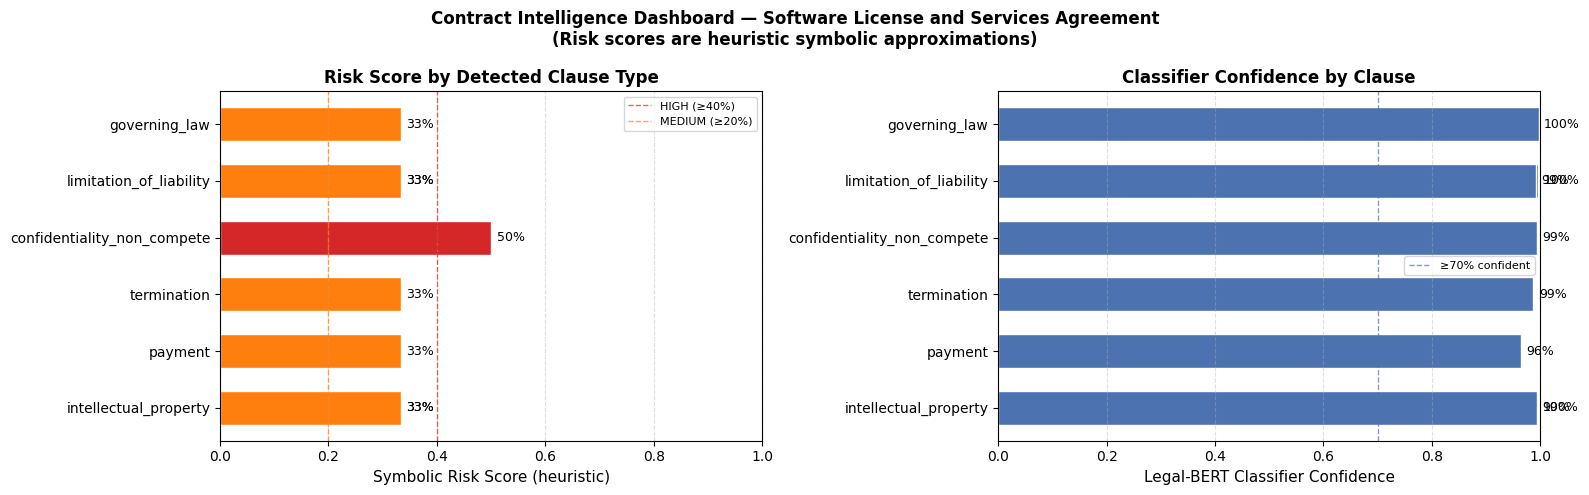

Risk dashboard saved.


In [16]:
# %% [markdown]
# ## Cell 16 — Risk Dashboard Visualisation (matplotlib-only)

# %%
clause_results = document_analysis["clause_results"]
valid_results  = [r for r in clause_results if r.get("clause_type", "unknown") != "unknown"]

labels      = [r["clause_type"]  for r in valid_results]
risk_scores = [r["risk_score"]   for r in valid_results]
confidences = [r["confidence"]   for r in valid_results]

risk_colors = ["#d62728" if s >= 0.4 else "#ff7f0e" if s >= 0.2 else "#2ca02c"
               for s in risk_scores]
conf_colors = ["#4C72B0" if c >= 0.7 else "#9b9b9b" for c in confidences]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: Risk scores ─────────────────────────────────────────────────────────
bars = axes[0].barh(labels, risk_scores, color=risk_colors, edgecolor="white", height=0.6)
axes[0].axvline(0.4, color="#d62728", linestyle="--", linewidth=1, alpha=0.7, label="HIGH (≥40%)")
axes[0].axvline(0.2, color="#ff7f0e", linestyle="--", linewidth=1, alpha=0.7, label="MEDIUM (≥20%)")
axes[0].set_xlabel("Symbolic Risk Score (heuristic)", fontsize=11)
axes[0].set_title("Risk Score by Detected Clause Type", fontsize=12, fontweight="bold")
axes[0].set_xlim(0, 1)
for bar, val in zip(bars, risk_scores):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                 f"{val:.0%}", va="center", fontsize=9)
axes[0].legend(fontsize=8)
axes[0].grid(axis="x", linestyle="--", alpha=0.4)

# ── Right: Classifier confidence ──────────────────────────────────────────────
bars2 = axes[1].barh(labels, confidences, color=conf_colors, edgecolor="white", height=0.6)
axes[1].axvline(0.7, color="#4C72B0", linestyle="--", linewidth=1, alpha=0.7, label="≥70% confident")
axes[1].set_xlabel("Legal-BERT Classifier Confidence", fontsize=11)
axes[1].set_title("Classifier Confidence by Clause", fontsize=12, fontweight="bold")
axes[1].set_xlim(0, 1)
for bar, val in zip(bars2, confidences):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                 f"{val:.0%}", va="center", fontsize=9)
axes[1].legend(fontsize=8)
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle(
    f"Contract Intelligence Dashboard — {document_analysis['contract_title']}\n"
    f"(Risk scores are heuristic symbolic approximations)",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "contract_risk_dashboard.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Risk dashboard saved.")

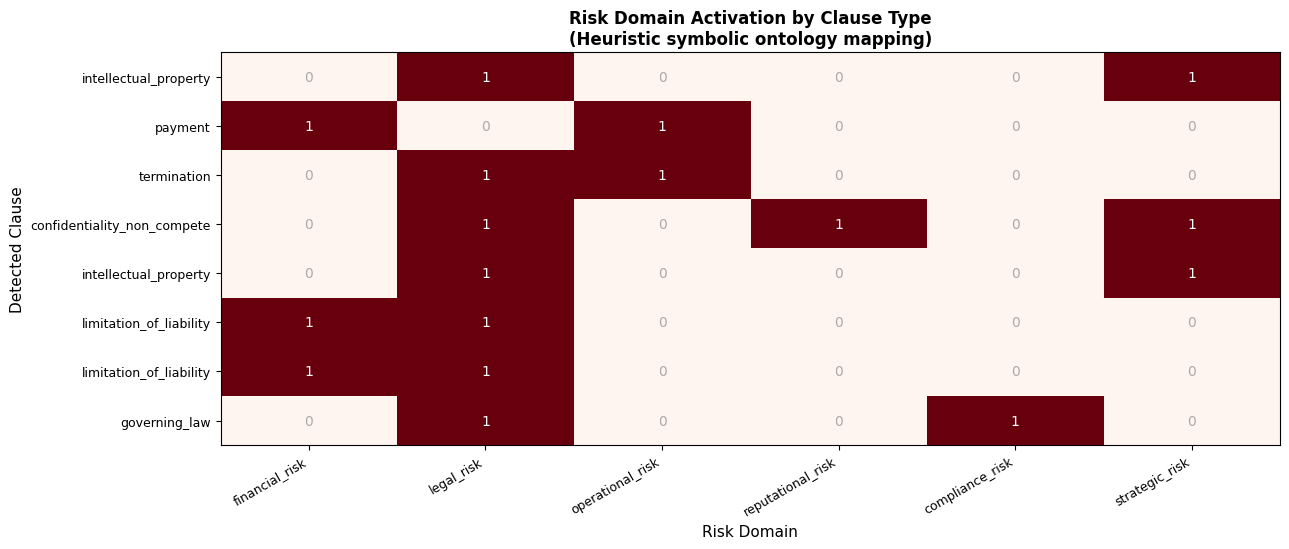

Risk domain heatmap saved.


In [17]:
# %% [markdown]
# ## Cell 17 — Risk Domain Activation Heatmap (matplotlib-only)

# %%
_ALL_RISK_DOMAIN_NAMES = [
    "financial_risk", "legal_risk", "operational_risk",
    "reputational_risk", "compliance_risk", "strategic_risk"
]

heatmap_arr = np.zeros((len(valid_results), len(_ALL_RISK_DOMAIN_NAMES)), dtype=int)

for i, r in enumerate(valid_results):
    for rd in r.get("risk_domains", []):
        if rd in _ALL_RISK_DOMAIN_NAMES:
            j = _ALL_RISK_DOMAIN_NAMES.index(rd)
            heatmap_arr[i, j] = 1

fig, ax = plt.subplots(figsize=(13, max(4, len(valid_results) * 0.7)))

im = ax.imshow(heatmap_arr, cmap="Reds", aspect="auto", vmin=0, vmax=1)

# Annotations
for i in range(heatmap_arr.shape[0]):
    for j in range(heatmap_arr.shape[1]):
        ax.text(j, i, str(heatmap_arr[i, j]),
                ha="center", va="center", fontsize=10,
                color="white" if heatmap_arr[i, j] == 1 else "#aaaaaa")

ax.set_xticks(range(len(_ALL_RISK_DOMAIN_NAMES)))
ax.set_yticks(range(len(valid_results)))
ax.set_xticklabels(_ALL_RISK_DOMAIN_NAMES, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Risk Domain", fontsize=11)
ax.set_ylabel("Detected Clause", fontsize=11)
ax.set_title(
    "Risk Domain Activation by Clause Type\n(Heuristic symbolic ontology mapping)",
    fontsize=12, fontweight="bold"
)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "risk_domain_activation.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Risk domain heatmap saved.")

In [18]:
# %% [markdown]
# ## Cell 18 — Export Full Intelligence Report

# %%
if EXPORT_OUTPUTS:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # ── JSON report ───────────────────────────────────────────────────────────
    report_json = _make_json_safe({
        "contract_title":      document_analysis["contract_title"],
        "generated_at":        timestamp,
        "llm_mode":            "real_api" if USE_REAL_LLM else "offline_fallback",
        "total_clauses":       document_analysis["total_clauses"],
        "valid_clauses":       document_analysis["valid_clauses"],
        "mean_risk_score":     document_analysis["mean_risk_score"],
        "max_risk_score":      document_analysis["max_risk_score"],
        "high_risk_clauses":   document_analysis["high_risk_clauses"],
        "clause_type_counts":  document_analysis["clause_type_counts"],
        "report_sections":     document_analysis["report_sections"],
        "clauses": [
            {
                "clause_text":            r.get("clause_text", "")[:300],
                "clause_type":            r.get("clause_type", ""),
                "confidence":             r.get("confidence", 0.0),
                "risk_score":             r.get("risk_score", 0.0),
                "risk_domains":           r.get("risk_domains", []),
                "legal_concepts":         r.get("legal_concepts", []),
                "plain_summary":          r.get("plain_summary", ""),
                "legal_implications":     r.get("legal_implications", ""),
                "business_implications":  r.get("business_implications", ""),
                "risk_interpretation":    r.get("risk_interpretation", ""),
            }
            for r in document_analysis["clause_results"]
        ]
    })

    json_path = os.path.join(OUTPUT_DIR, "contract_intelligence_report.json")
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(report_json, f, indent=2, ensure_ascii=False)

    # ── CSV ───────────────────────────────────────────────────────────────────
    csv_rows = [
        {
            "clause_text":            r.get("clause_text", "")[:300],
            "clause_type":            r.get("clause_type", ""),
            "confidence":             r.get("confidence", 0.0),
            "risk_score":             r.get("risk_score", 0.0),
            "risk_domains":           "|".join(r.get("risk_domains", [])),
            "legal_concepts":         "|".join(r.get("legal_concepts", [])),
            "plain_summary":          r.get("plain_summary", ""),
            "legal_implications":     r.get("legal_implications", ""),
            "business_implications":  r.get("business_implications", ""),
            "risk_interpretation":    r.get("risk_interpretation", ""),
        }
        for r in document_analysis["clause_results"]
    ]
    df_export = pd.DataFrame(csv_rows)
    csv_path  = os.path.join(OUTPUT_DIR, "clause_analysis_results.csv")
    df_export.to_csv(csv_path, index=False, encoding="utf-8")

    # ── Plain text ────────────────────────────────────────────────────────────
    txt_path = os.path.join(OUTPUT_DIR, "contract_report.txt")
    rs       = document_analysis["report_sections"]
    with open(txt_path, "w", encoding="utf-8") as f:
        f.write(f"CONTRACT INTELLIGENCE REPORT\n{'='*65}\n")
        f.write(f"Contract:   {document_analysis['contract_title']}\n")
        f.write(f"Generated:  {timestamp}\n")
        f.write(f"LLM Mode:   {'Real API' if USE_REAL_LLM else 'Offline Fallback'}\n\n")
        f.write("NOTE: Symbolic risk scores and ontology reasoning are heuristic\n"
                "approximations. LLM explanations are generative and require\n"
                "qualified legal review before operational use.\n\n")
        for section in _CONTRACT_SECTIONS:
            val = rs.get(section, "")
            if val:
                f.write(f"\n{section}:\n{val}\n")
        f.write(f"\n\n{'='*65}\nCLAUSE-LEVEL ANALYSIS\n{'='*65}\n")
        for i, r in enumerate(document_analysis["clause_results"], 1):
            f.write(f"\n[{i}] {r.get('clause_type','unknown').upper()} "
                    f"(risk: {r.get('risk_score',0):.0%})\n{'─'*50}\n")
            f.write(f"Text:     {r.get('clause_text','')[:200]}...\n\n")
            for label, key in [("Plain English", "plain_summary"),
                                ("Legal",         "legal_implications"),
                                ("Business",      "business_implications"),
                                ("Risk",          "risk_interpretation")]:
                val = r.get(key, "")
                if val:
                    f.write(f"{label}:\n{val}\n\n")

    print(f"Outputs exported to: {OUTPUT_DIR}/")
    print(f"Exported files:")
    for fn in sorted(os.listdir(OUTPUT_DIR)):
        size = os.path.getsize(os.path.join(OUTPUT_DIR, fn))
        print(f"  {fn:<45s}  {size:>8,} bytes")
else:
    print("EXPORT_OUTPUTS = False — skipping file export.")

Outputs exported to: nb03_outputs/
Exported files:
  clause_analysis_results.csv                      10,913 bytes
  contract_intelligence_report.json                15,273 bytes
  contract_report.txt                              13,312 bytes
  contract_risk_dashboard.png                     108,440 bytes
  risk_domain_activation.png                       83,797 bytes


In [19]:
# %% [markdown]
# ## Cell 19 — Notebook 03 Summary
#
# | Component                    | Detail                                              |
# |------------------------------|-----------------------------------------------------|
# | LLM mode                     | Dual: real API / offline deterministic fallback     |
# | Caching                      | MD5-keyed JSON cache, clause + contract level       |
# | Clause segmentation          | Rule-based heuristic (header + paragraph fallback)  |
# | analyse_clause()             | 3-layer: Legal-BERT → Ontology → LLM/fallback       |
# | analyse_document()           | Full pipeline + contract-level report               |
# | Section parsing              | Robust regex, tolerates malformed LLM output        |
# | Error handling               | All layers wrapped, pipeline never crashes          |
# | Visualisations               | matplotlib-only: risk dashboard + activation heatmap|
# | Exports                      | JSON (UTF-8), CSV, plain text — all deterministic   |
#
# **Heuristic disclaimer:**
# Symbolic risk scores, ontology mappings, and clause segmentation are
# rule-based approximations. LLM explanations are generative and should
# not substitute qualified legal advice.

print("Notebook 03 — COMPLETE (submission-quality)")
print(f"\nPipeline mode: {'Real LLM (Anthropic API)' if USE_REAL_LLM else 'Offline Fallback (deterministic)'}")
print(f"Cache location: {CACHE_DIR}/")
print(f"Output location: {OUTPUT_DIR}/")
print("\nFull hybrid AI system:")
print("  NB01  Neural AI      → Legal-BERT clause classification")
print("  NB02  Symbolic AI    → Ontology enrichment & KRR reasoning")
print("  NB03  Generative AI  → LLM natural language explanation")

Notebook 03 — COMPLETE (submission-quality)

Pipeline mode: Offline Fallback (deterministic)
Cache location: nb03_cache/
Output location: nb03_outputs/

Full hybrid AI system:
  NB01  Neural AI      → Legal-BERT clause classification
  NB02  Symbolic AI    → Ontology enrichment & KRR reasoning
  NB03  Generative AI  → LLM natural language explanation
